In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [62]:
pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 13.2 MB/s eta 0:00:00

   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ---------------------------------------- 4/4 [nltk]

Note: you may need to restart the kernel to use updated packages.


In [64]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [65]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sriha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
df = pd.read_csv(r"C:\Users\sriha\Desktop\movies_dataset_10000.csv")

In [5]:
df

,Unnamed: 0,title,year,kind,genre,rating,vote,country,language,cast,director,composer,writer,runtime
0,0,The Last Journey 484,2003,tv series,Action,3.5,22194,UK,German,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Steven Spielberg,A R Rahman,Aaron Sorkin,112
1,1,Shadow Rise 157,2017,tv series,Drama,3.4,75048,UK,French,"Amitabh Bachchan, Chris Evans, John Smith",James Cameron,A R Rahman,Raju Murugan,136
2,2,Broken Paths 403,1987,tv series,Drama,6.6,72803,UK,English,"John Smith, Amitabh Bachchan, Emma Watson",James Cameron,Hans Zimmer,Aaron Sorkin,180
3,3,Broken Paths 72,2012,movie,Romance,1.3,10905,UK,English,"Emma Watson, John Smith, Scarlett Johansson",Christopher Nolan,A R Rahman,Aaron Sorkin,95
4,4,Broken Paths 443,2013,tv series,Thriller,8.5,22144,UK,Hindi,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Christopher Nolan,John Williams,Aaron Sorkin,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,Shadow Rise 424,1992,tv series,Comedy,7.5,40952,Australia,German,"Scarlett Johansson, Emma Watson, Amitabh Bachchan",Rajkumar Hirani,Hans Zimmer,Raju Murugan,134
9996,9996,Golden Dreams 256,2022,tv series,Action,7.3,25167,USA,Hindi,"Emma Watson, John Smith, Amitabh Bachchan",James Cameron,John Williams,Quentin Tarantino,119
9997,9997,Golden Dreams 338,2004,tv series,Action,4.4,80947,UK,French,"Chris Evans, Emma Watson, John Smith",James Cameron,Hans Zimmer,Raju Murugan,86
9998,9998,Shadow Rise 29,2025,movie,Action,3.6,62272,India,French,"John Smith, Emma Watson, Chris Evans",Steven Spielberg,Hans Zimmer,Quentin Tarantino,66


### Data Pre-processing

In [6]:
df.head()

,Unnamed: 0,title,year,kind,genre,rating,vote,country,language,cast,director,composer,writer,runtime
0,0,The Last Journey 484,2003,tv series,Action,3.5,22194,UK,German,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Steven Spielberg,A R Rahman,Aaron Sorkin,112
1,1,Shadow Rise 157,2017,tv series,Drama,3.4,75048,UK,French,"Amitabh Bachchan, Chris Evans, John Smith",James Cameron,A R Rahman,Raju Murugan,136
2,2,Broken Paths 403,1987,tv series,Drama,6.6,72803,UK,English,"John Smith, Amitabh Bachchan, Emma Watson",James Cameron,Hans Zimmer,Aaron Sorkin,180
3,3,Broken Paths 72,2012,movie,Romance,1.3,10905,UK,English,"Emma Watson, John Smith, Scarlett Johansson",Christopher Nolan,A R Rahman,Aaron Sorkin,95
4,4,Broken Paths 443,2013,tv series,Thriller,8.5,22144,UK,Hindi,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Christopher Nolan,John Williams,Aaron Sorkin,139


##### View the list of columns

In [8]:
df.columns

Index(['Unnamed: 0', 'title', 'year', 'kind', 'genre', 'rating', 'vote',
       'country', 'language', 'cast', 'director', 'composer', 'writer',
       'runtime'],
      dtype='object')

##### Dropping unnamed column

In [10]:
df = df.drop("Unnamed: 0",axis = 1)

##### Dataset after removing a column

In [12]:
df

,title,year,kind,genre,rating,vote,country,language,cast,director,composer,writer,runtime
0,The Last Journey 484,2003,tv series,Action,3.5,22194,UK,German,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Steven Spielberg,A R Rahman,Aaron Sorkin,112
1,Shadow Rise 157,2017,tv series,Drama,3.4,75048,UK,French,"Amitabh Bachchan, Chris Evans, John Smith",James Cameron,A R Rahman,Raju Murugan,136
2,Broken Paths 403,1987,tv series,Drama,6.6,72803,UK,English,"John Smith, Amitabh Bachchan, Emma Watson",James Cameron,Hans Zimmer,Aaron Sorkin,180
3,Broken Paths 72,2012,movie,Romance,1.3,10905,UK,English,"Emma Watson, John Smith, Scarlett Johansson",Christopher Nolan,A R Rahman,Aaron Sorkin,95
4,Broken Paths 443,2013,tv series,Thriller,8.5,22144,UK,Hindi,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Christopher Nolan,John Williams,Aaron Sorkin,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Shadow Rise 424,1992,tv series,Comedy,7.5,40952,Australia,German,"Scarlett Johansson, Emma Watson, Amitabh Bachchan",Rajkumar Hirani,Hans Zimmer,Raju Murugan,134
9996,Golden Dreams 256,2022,tv series,Action,7.3,25167,USA,Hindi,"Emma Watson, John Smith, Amitabh Bachchan",James Cameron,John Williams,Quentin Tarantino,119
9997,Golden Dreams 338,2004,tv series,Action,4.4,80947,UK,French,"Chris Evans, Emma Watson, John Smith",James Cameron,Hans Zimmer,Raju Murugan,86
9998,Shadow Rise 29,2025,movie,Action,3.6,62272,India,French,"John Smith, Emma Watson, Chris Evans",Steven Spielberg,Hans Zimmer,Quentin Tarantino,66


##### No.of rows and columns

In [14]:
df.shape

(10000, 13)

##### Checking for no.of missing values

In [15]:
df.isnull().sum()

title       0
year        0
kind        0
genre       0
rating      0
vote        0
country     0
language    0
cast        0
director    0
composer    0
writer      0
runtime     0
dtype: int64

##### Checking Datatypes

In [17]:
df.dtypes

title        object
year          int64
kind         object
genre        object
rating      float64
vote          int64
country      object
language     object
cast         object
director     object
composer     object
writer       object
runtime       int64
dtype: object

##### Changing "Rating" column's dtype from 'float' to 'int'

In [20]:
df["rating"] = df["rating"].astype(int)

##### Checking Dataypes after changing dtype

In [21]:
df.dtypes

title       object
year         int64
kind        object
genre       object
rating       int64
vote         int64
country     object
language    object
cast        object
director    object
composer    object
writer      object
runtime      int64
dtype: object

##### Creating a composite key using title and release year
##### Add the 'Composite_Key' column

In [22]:
df['id'] = df['title'] + '_' + df['year'].astype(str)

##### Move 'Composite_Key' column to the beginning

In [23]:
df = df[['id'] + [col for col in df.columns if col != 'id']]

##### View the list of columns

In [24]:
df.columns

Index(['id', 'title', 'year', 'kind', 'genre', 'rating', 'vote', 'country',
       'language', 'cast', 'director', 'composer', 'writer', 'runtime'],
      dtype='object')

##### Remove brackets from genre, country, language, director, cast and writer columns

In [25]:
columns = ['genre','country','language','cast','director','writer']

for column in columns:
    df[column] = df[column].astype(str).str.strip('[]')

##### Remove quotes from genre, country, language, director, cast, writer columns

In [26]:
quote_columns = ['genre','country','language','cast','director','writer']

for quote in quote_columns:
    df[quote] = df[quote].str.replace(r"\'","", regex=True)

In [28]:
df.head()

,id,title,year,kind,genre,rating,vote,country,language,cast,director,composer,writer,runtime
0,The Last Journey 484_2003,The Last Journey 484,2003,tv series,Action,3,22194,UK,German,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Steven Spielberg,A R Rahman,Aaron Sorkin,112
1,Shadow Rise 157_2017,Shadow Rise 157,2017,tv series,Drama,3,75048,UK,French,"Amitabh Bachchan, Chris Evans, John Smith",James Cameron,A R Rahman,Raju Murugan,136
2,Broken Paths 403_1987,Broken Paths 403,1987,tv series,Drama,6,72803,UK,English,"John Smith, Amitabh Bachchan, Emma Watson",James Cameron,Hans Zimmer,Aaron Sorkin,180
3,Broken Paths 72_2012,Broken Paths 72,2012,movie,Romance,1,10905,UK,English,"Emma Watson, John Smith, Scarlett Johansson",Christopher Nolan,A R Rahman,Aaron Sorkin,95
4,Broken Paths 443_2013,Broken Paths 443,2013,tv series,Thriller,8,22144,UK,Hindi,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Christopher Nolan,John Williams,Aaron Sorkin,139


##### Rename column

In [29]:
df.rename(columns = {'kind':'category'}, inplace = True)

In [30]:
df.columns

Index(['id', 'title', 'year', 'category', 'genre', 'rating', 'vote', 'country',
       'language', 'cast', 'director', 'composer', 'writer', 'runtime'],
      dtype='object')

##### Dropping extra columns

In [31]:
column_to_drop = ['composer']
df.drop(column_to_drop, axis=1, inplace=True)
df.columns

Index(['id', 'title', 'year', 'category', 'genre', 'rating', 'vote', 'country',
       'language', 'cast', 'director', 'writer', 'runtime'],
      dtype='object')

##### Check for no of duplicates present

In [32]:
len(df)-len(df.drop_duplicates())

0

In [33]:
df.shape

(10000, 13)

In [34]:
df["category"].value_counts()

category
movie        5041
tv series    4959
Name: count, dtype: int64

In [35]:
df_new = df[~df['category'].isin(['tv short', 'video game'])]
df_new["category"].value_counts()

category
movie        5041
tv series    4959
Name: count, dtype: int64

##### Replacing 'tv series' to 'movie'

In [42]:
df_new.replace(regex=r'tv series', value='movie', inplace=True)

In [43]:
df_new["category"].value_counts()

category
movie    10000
Name: count, dtype: int64

In [44]:
df_new.head()

,id,title,year,category,genre,rating,vote,country,language,cast,director,writer,runtime
0,The Last Journey 484_2003,The Last Journey 484,2003,movie,Action,3,22194,UK,German,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Steven Spielberg,Aaron Sorkin,112
1,Shadow Rise 157_2017,Shadow Rise 157,2017,movie,Drama,3,75048,UK,French,"Amitabh Bachchan, Chris Evans, John Smith",James Cameron,Raju Murugan,136
2,Broken Paths 403_1987,Broken Paths 403,1987,movie,Drama,6,72803,UK,English,"John Smith, Amitabh Bachchan, Emma Watson",James Cameron,Aaron Sorkin,180
3,Broken Paths 72_2012,Broken Paths 72,2012,movie,Romance,1,10905,UK,English,"Emma Watson, John Smith, Scarlett Johansson",Christopher Nolan,Aaron Sorkin,95
4,Broken Paths 443_2013,Broken Paths 443,2013,movie,Thriller,8,22144,UK,Hindi,"Scarlett Johansson, Chris Evans, Amitabh Bachchan",Christopher Nolan,Aaron Sorkin,139


In [45]:
df_new.to_csv('cleaned_imdb_dataset.csv')

# Exploratory Data Analysis(EDA)

### Top 10 best performing movies

C:\Users\sriha\AppData\Local\Temp\ipykernel_2688\2256036961.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot = ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)


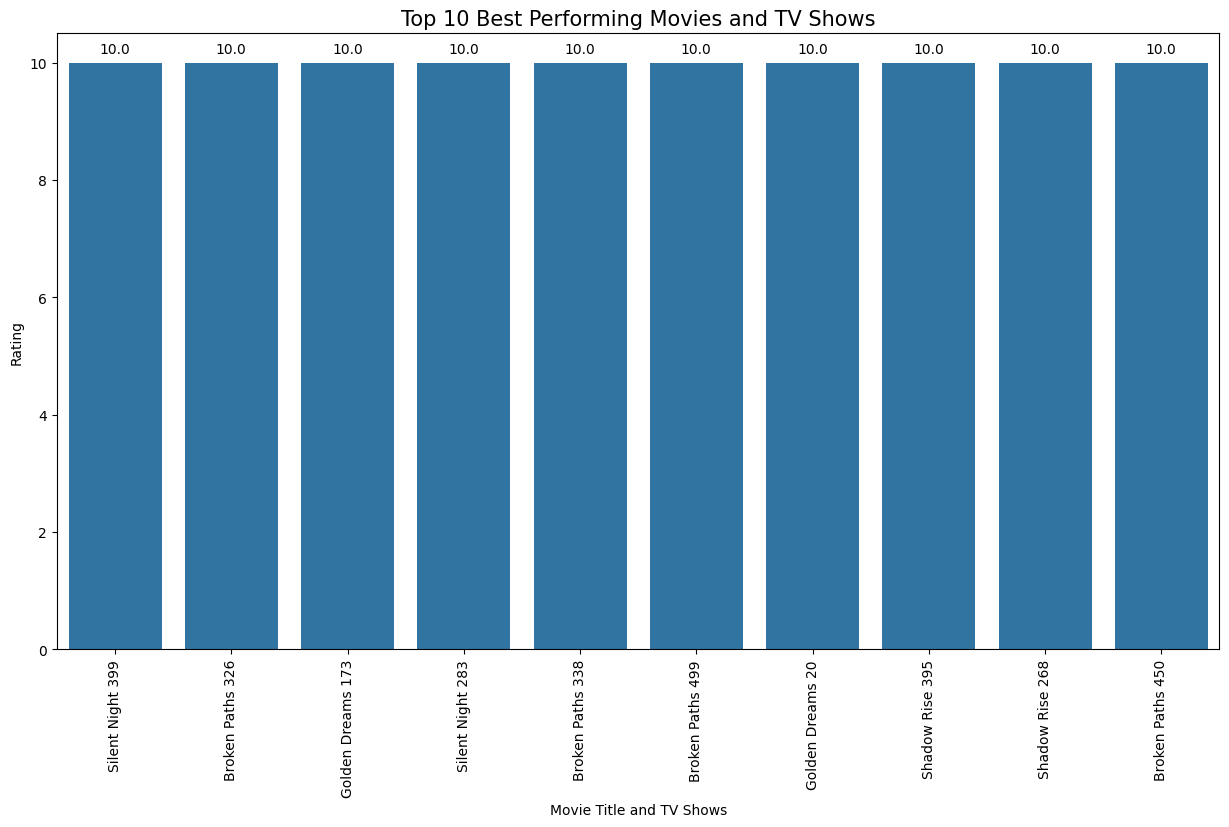

In [46]:
fig = plt.figure(figsize = (15, 8))
ax = sns.barplot(x = 'title', y = 'rating', data = df_new.sort_values('rating', ascending=False)[0:10])

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points')
    
plot = ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
plt.xlabel('Movie Title and TV Shows')
plt.ylabel('Rating')
plt.title('Top 10 Best Performing Movies and TV Shows', fontsize = 15)

plt.yticks([0, 2, 4, 6, 8, 10])

plt.show()

### Distribution of category

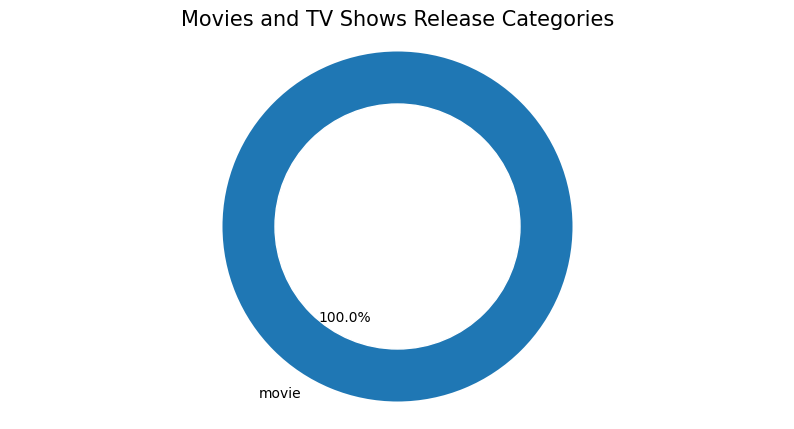

In [47]:
category_counts = df_new['category'].value_counts()

plt.figure(figsize=(10, 5))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=60, wedgeprops=dict(width=0.4))
plt.title("Movies and TV Shows Release Categories", fontsize=15)
plt.gca().add_artist(plt.Circle((0, 0), 0.7, color='white'))  
plt.axis('equal')  
plt.show()

### Genre with most releases

In [48]:
genres_series = df_new['genre'].str.split(',\s*').explode()

genre_counts = genres_series.value_counts().reset_index()

genre_counts.columns = ['genre', 'count']
genre_counts.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\sriha\AppData\Local\Temp\ipykernel_2688\106365506.py:1: SyntaxWarning: invalid escape sequence '\s'
  genres_series = df_new['genre'].str.split(',\s*').explode()


,genre,count
0,Action,2057
1,Comedy,2054
2,Drama,2012
3,Thriller,1974
4,Romance,1903


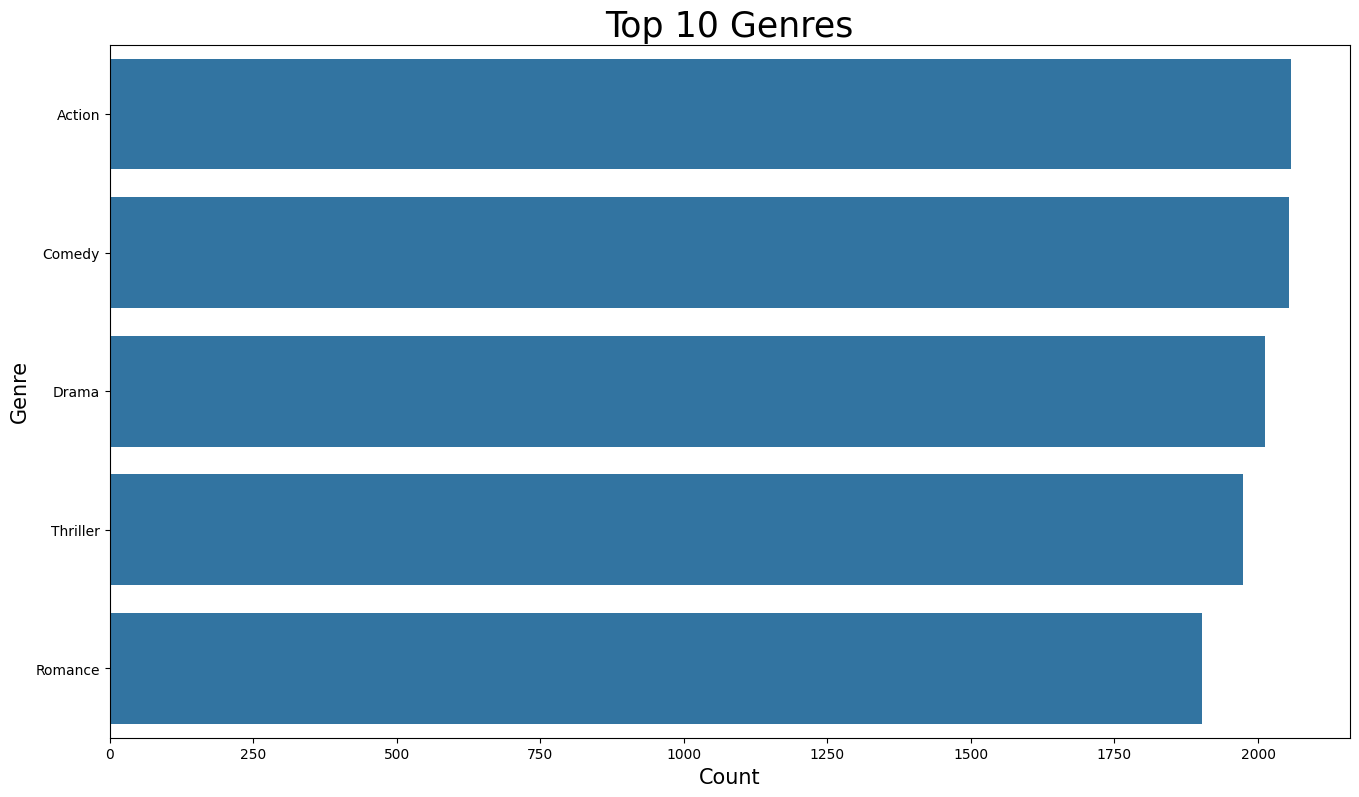

In [49]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'genre', data = genre_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Genres", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Genre', fontsize = 15)
plt.show()

### Total no.of releases each year

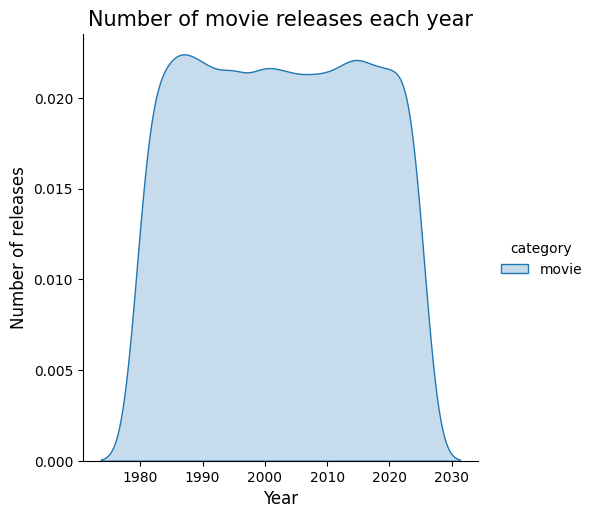

In [50]:
sns.displot(df_new, x="year", hue="category", kind="kde", fill=True)
plt.title("Number of movie releases each year", fontsize = 15)
plt.ylabel('Number of releases', fontsize = 12)
plt.xlabel('Year', fontsize = 12)
plt.show()

### Top 10 countries with most releases

In [51]:
country_series = df_new['country'].str.split(',\s*').explode()

country_counts = country_series.value_counts().reset_index()

country_counts.columns = ['country', 'count']
country_counts.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\sriha\AppData\Local\Temp\ipykernel_2688\499992663.py:1: SyntaxWarning: invalid escape sequence '\s'
  country_series = df_new['country'].str.split(',\s*').explode()


,country,count
0,UK,2024
1,Canada,2019
2,India,2018
3,USA,2013
4,Australia,1926


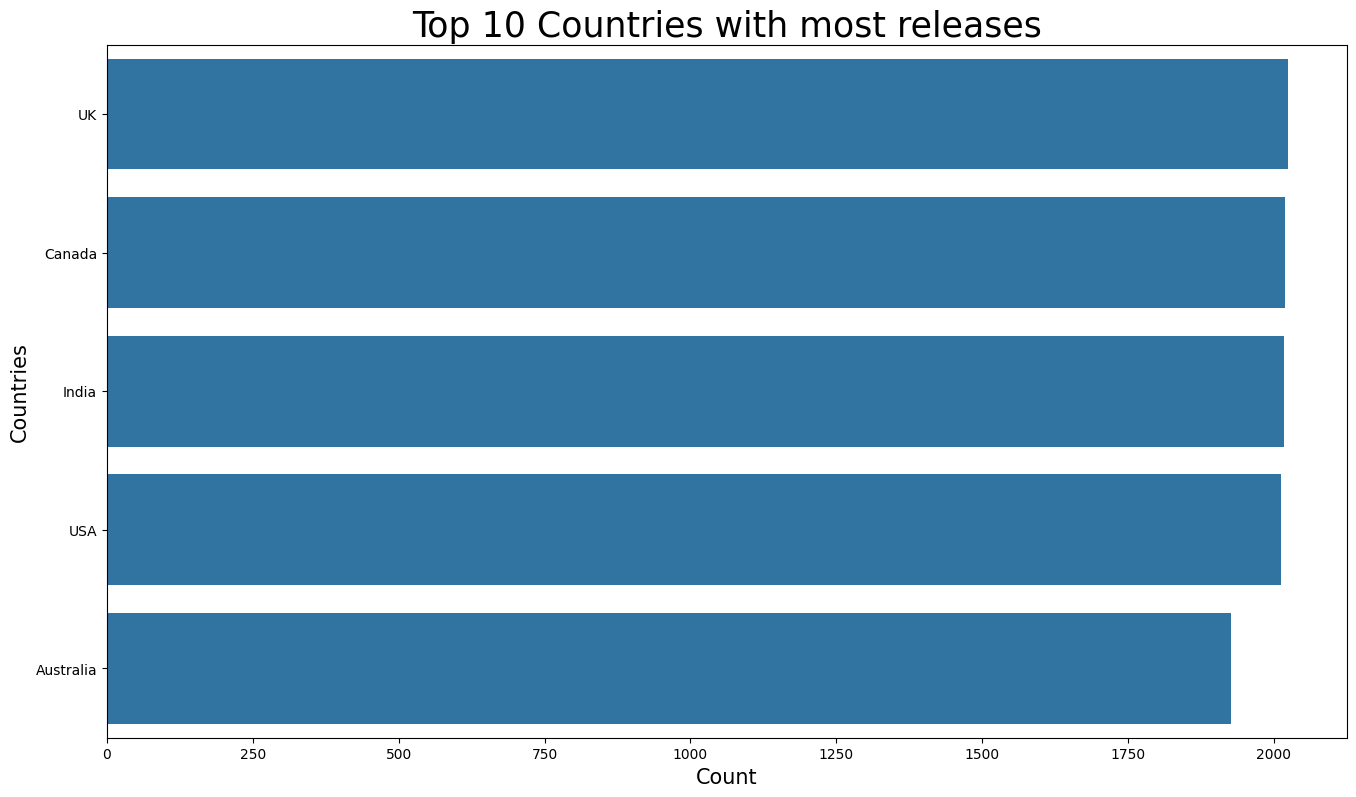

In [52]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'country', data = country_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Countries with most releases", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Countries', fontsize = 15)
plt.show()

### Top 10 languages

In [55]:
language_series = df_new['language'].str.split(',\s*').explode()

language_counts = language_series.value_counts().reset_index()

language_counts.columns = ['language', 'count']
language_counts.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\sriha\AppData\Local\Temp\ipykernel_2688\259075235.py:1: SyntaxWarning: invalid escape sequence '\s'
  language_series = df_new['language'].str.split(',\s*').explode()


,language,count
0,German,2080
1,French,2013
2,Hindi,1993
3,English,1988
4,Spanish,1926


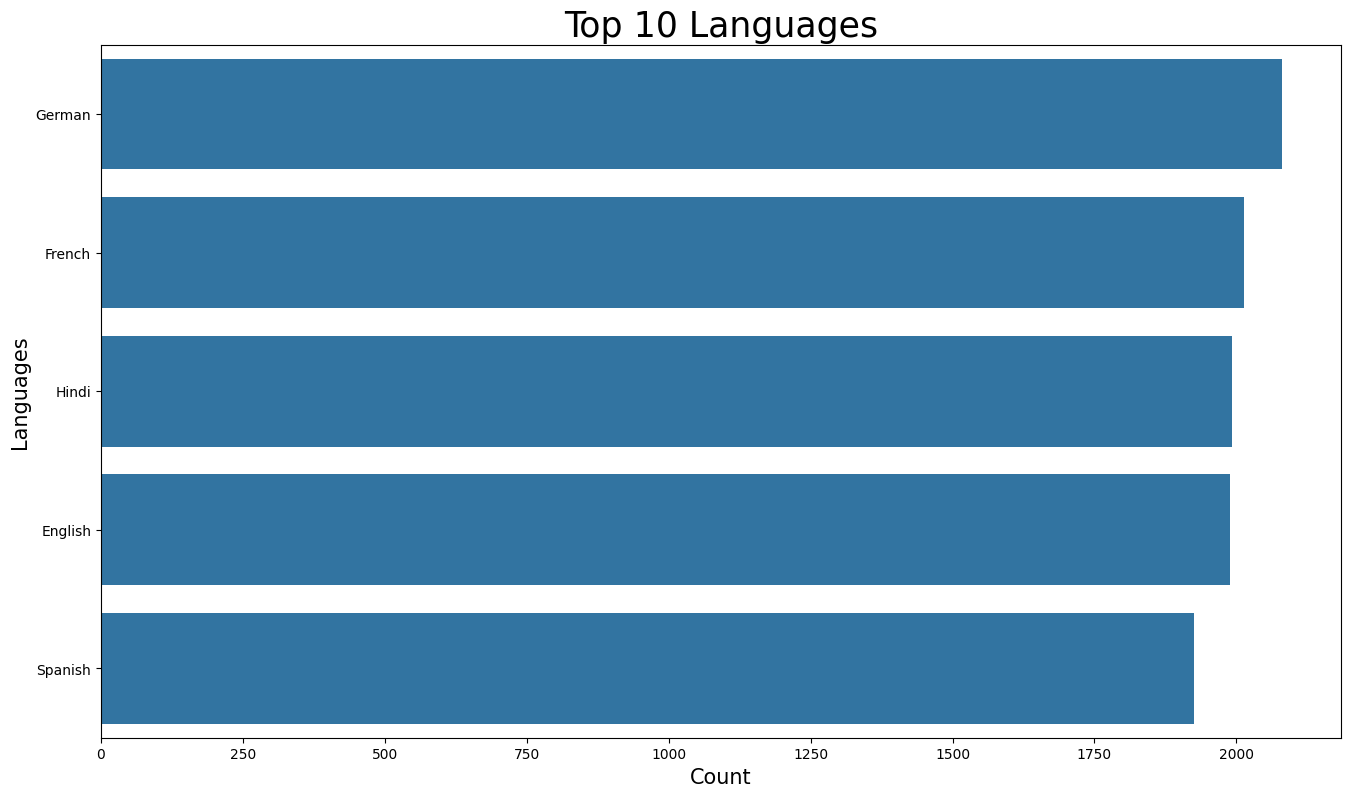

In [56]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'language', data = language_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Languages", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Languages', fontsize = 15)
plt.show()

### Top 10 Directors

In [57]:
director_series = df_new['director'].str.split(',\s*').explode()

director_counts = director_series.value_counts().reset_index()

director_counts.columns = ['director', 'count']
director_counts.head()

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\sriha\AppData\Local\Temp\ipykernel_2688\2852219178.py:1: SyntaxWarning: invalid escape sequence '\s'
  director_series = df_new['director'].str.split(',\s*').explode()


,director,count
0,Christopher Nolan,2537
1,Steven Spielberg,2529
2,James Cameron,2520
3,Rajkumar Hirani,2414


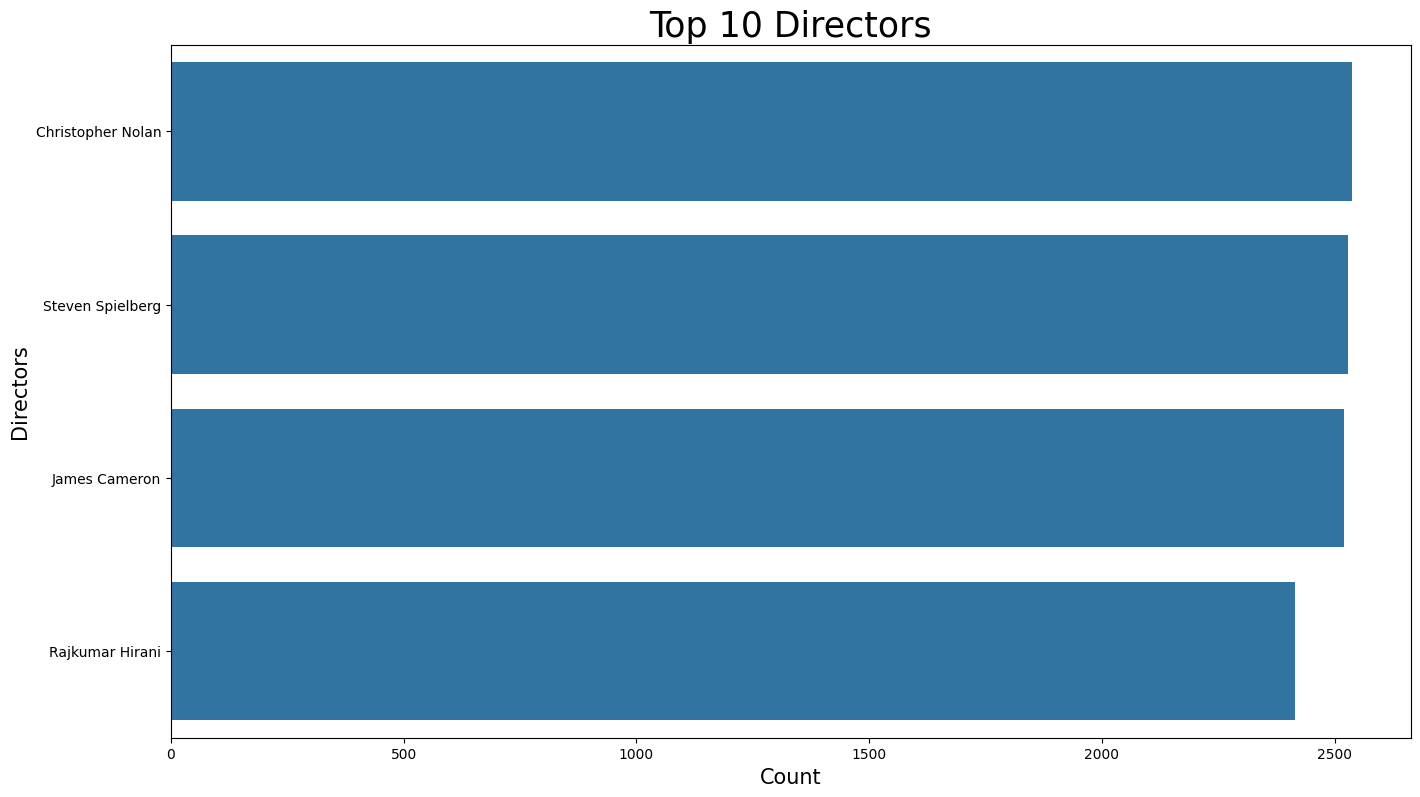

In [58]:
plt.figure(figsize = (16, 9))
ax = sns.barplot(x = 'count', y = 'director', data = director_counts.sort_values('count', ascending=False)[0:10])
plt.title("Top 10 Directors", fontsize = 25)
plt.xlabel('Count', fontsize = 15)
plt.ylabel('Directors', fontsize = 15)
plt.show()

### Wordcloud for Cast

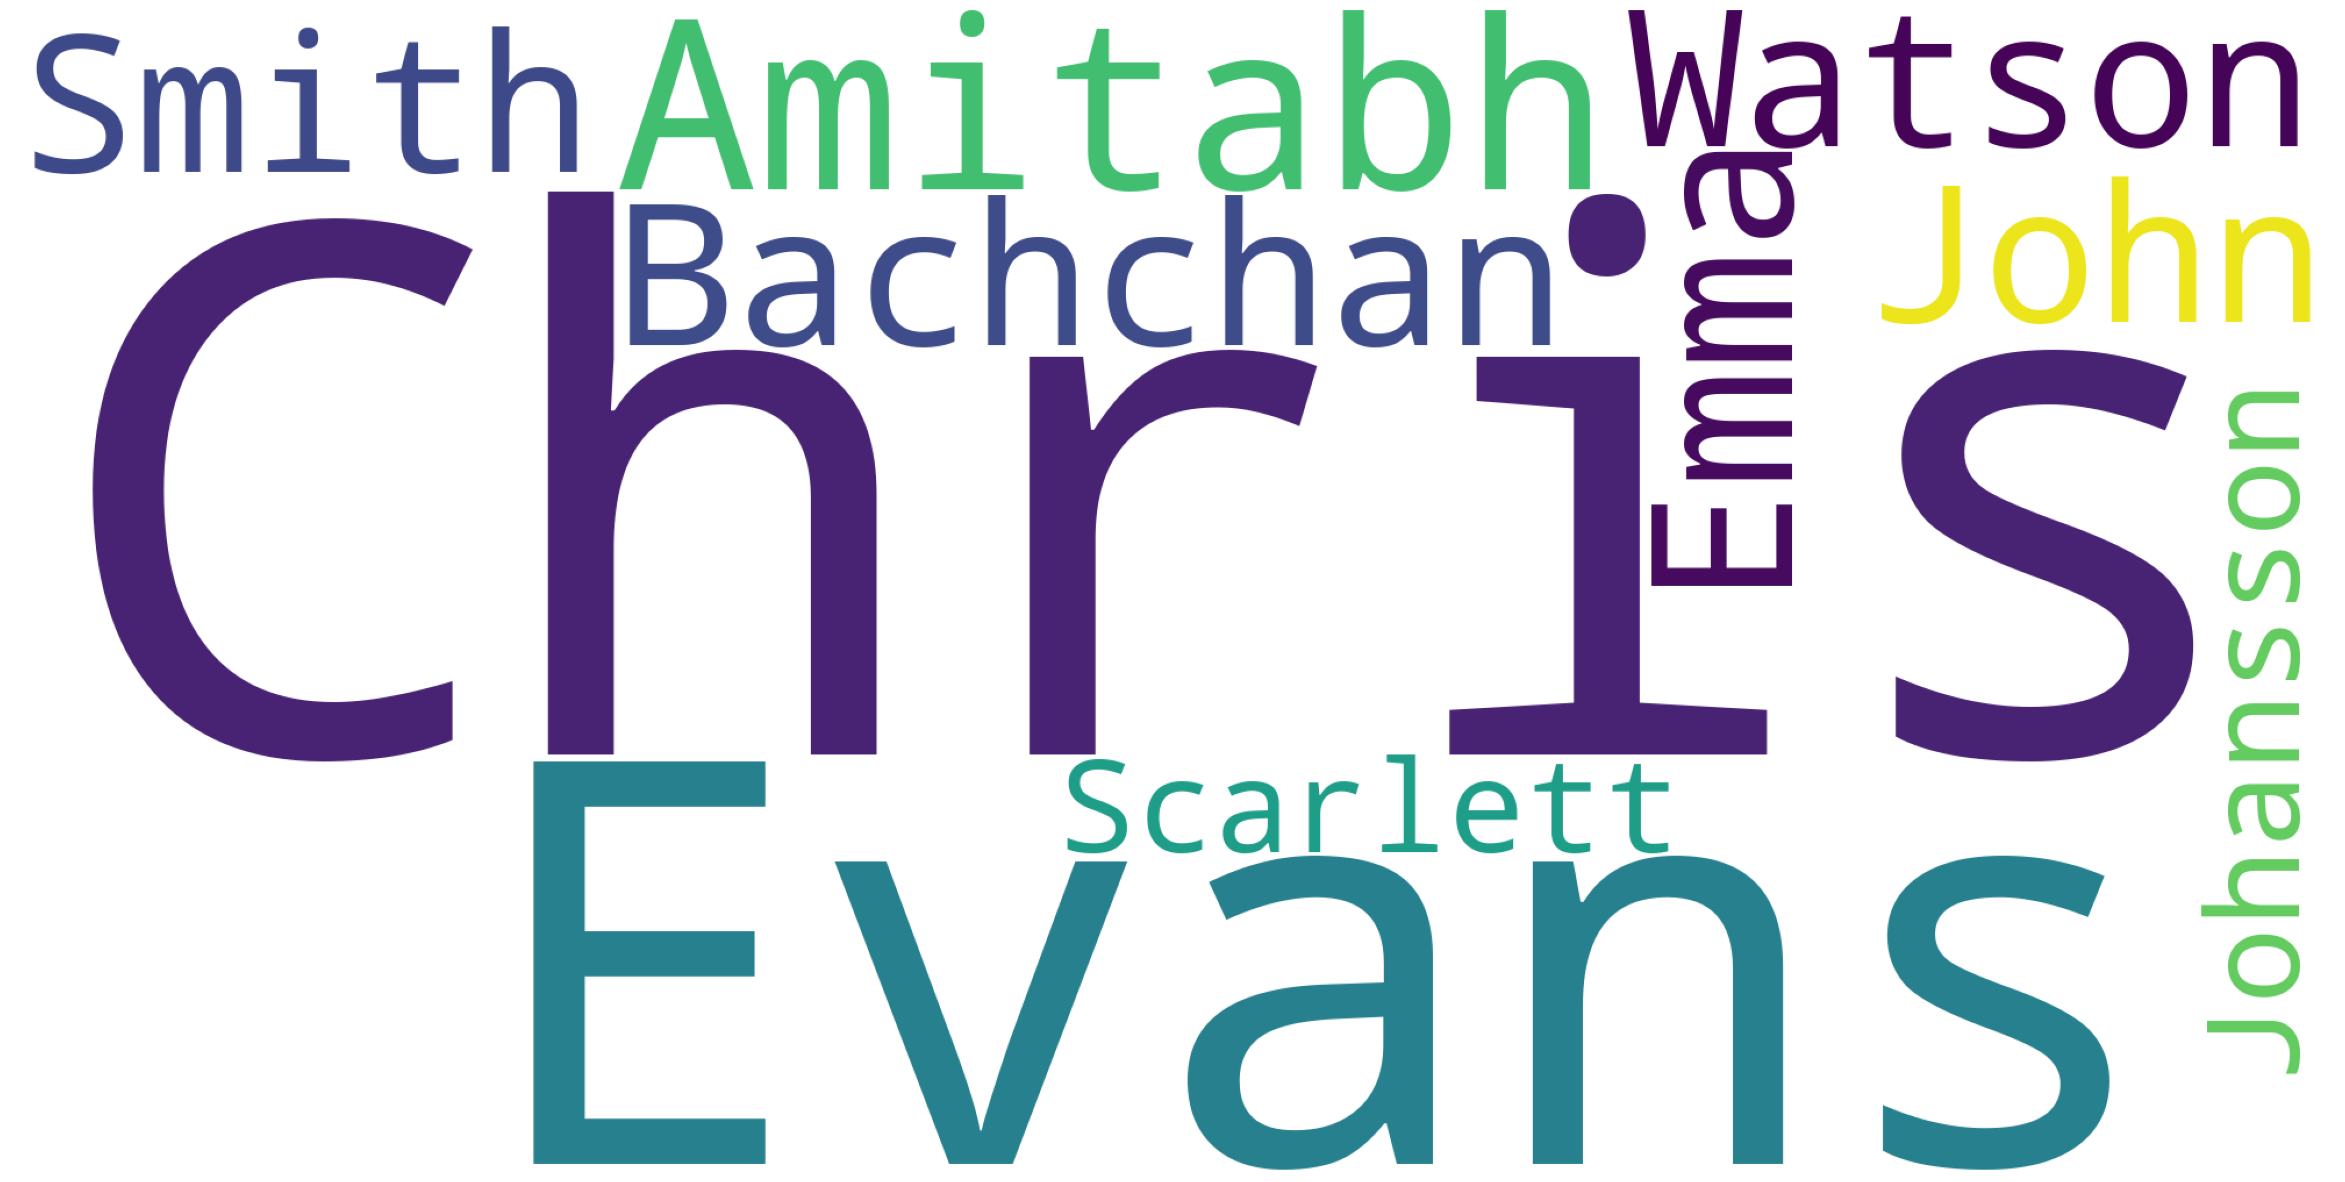

In [67]:
stop_words = set(stopwords.words('english'))
df_new.loc[:, 'cast_no_stopwords'] = df_new['cast'].apply(lambda x: [item for item in str(x).split() if item not in stop_words])

all_words = list([a for b in df_new['cast_no_stopwords'].tolist() for a in b])
all_words_str = ' '.join(all_words) 

def plot_cloud(wordcloud):
    plt.figure(figsize=(30, 20))
    plt.imshow(wordcloud) 
    plt.axis("off");

wordcloud = WordCloud(width = 2000, height = 1000, random_state=1, background_color='white', 
                      colormap='viridis', collocations=False).generate(all_words_str)
plot_cloud(wordcloud)

### Time series of Ratings

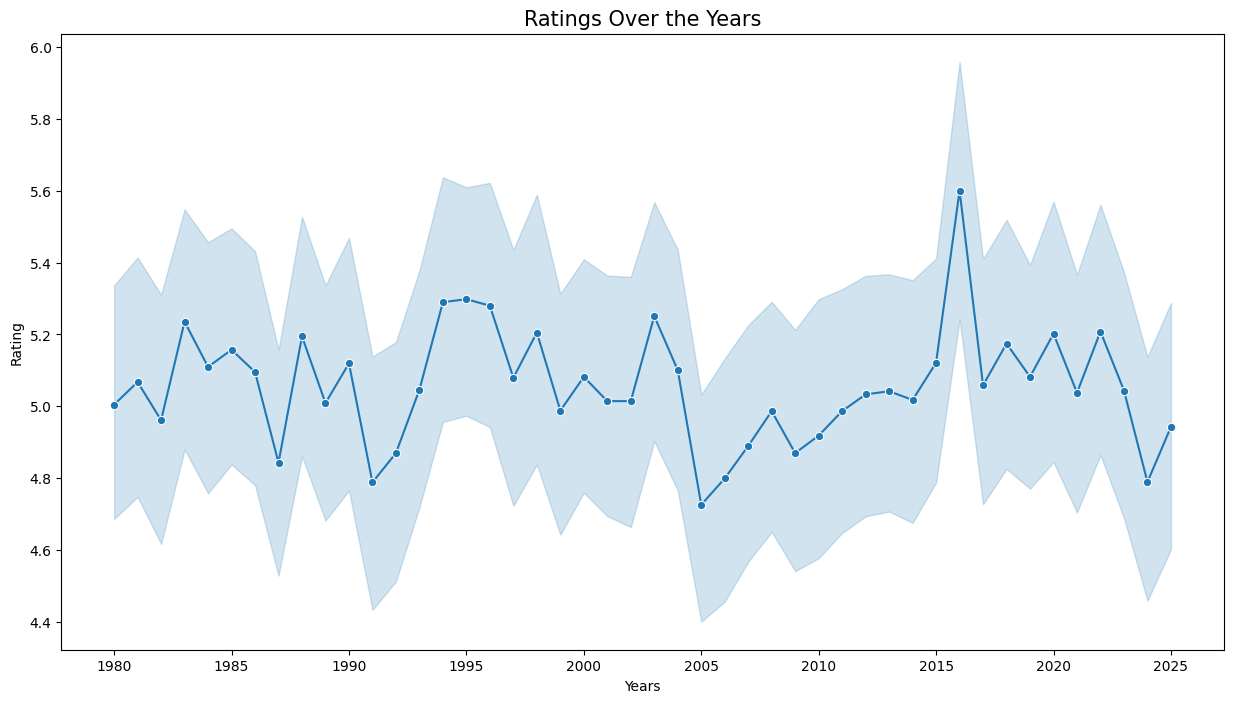

In [68]:
plt.figure(figsize=(15, 8))
ax = sns.lineplot(x='year', y='rating', data=df_new, marker='o')

plt.xticks(range(df_new['year'].min(), df_new['year'].max() + 1, 5))

plt.xlabel('Years')
plt.ylabel('Rating')
plt.title('Ratings Over the Years', fontsize=15)
plt.show()

### Relationship between Rating and Vote

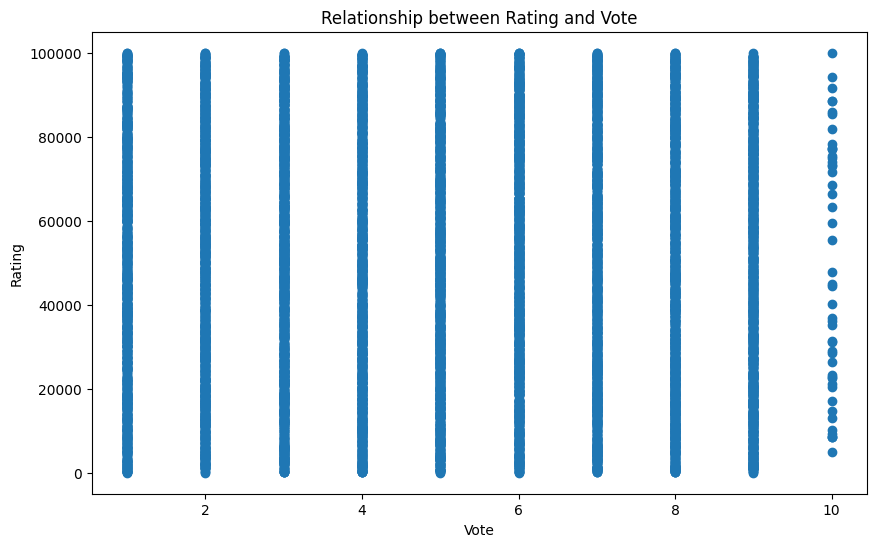

In [69]:
plt.figure(figsize=(10, 6))
plt.scatter(x = 'rating', y = 'vote', data = df_new)
plt.xlabel('Vote')
plt.ylabel('Rating')
plt.title('Relationship between Rating and Vote')
plt.show()